# Практика 3. Графовый анализ мошеннических транзакций

In [33]:
!pip install pandas networkx matplotlib plotly pyvis


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import os
from pathlib import Path

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

from pyvis.network import Network
from IPython.display import display, HTML

## 1. Настройки и имена столбцов

In [35]:
DATA_PATH = Path("FinFraud_Labelled.csv")

In [36]:
RAW_COLUMNS = [
    "label",                    # 0
    "sender_user",              # 1
    "receiver_user",            # 2
    "sender_acc",               # 3
    "receiver_acc",             # 4
    "amount",                   # 5
    "tx_type",                  # 6
    "status",                   # 7
    "sender_balance_before",    # 8
    "sender_balance_after",     # 9
    "receiver_balance_before",  # 10
    "receiver_balance_after",   # 11
    "flag_12",                  # 12
    "flag_13",                  # 13
    "flag_14",                  # 14
    "flag_15",                  # 15
    "sender_time",              # 16
    "receiver_time",            # 17
    "sender_acc_dup",           # 18
    "service_19",               # 19
    "service_20",               # 20
    "transaction_id",           # 21
    "tx_time",                  # 22
    "sender_role",              # 23
    "receiver_role"             # 24
]

## 2. Загрузка и подготовка

In [37]:
def load_transactions(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Файл не найден: {path}")

    raw = pd.read_csv(path, header=None, names=["raw_line"], encoding="utf-8")
    parts = raw["raw_line"].astype(str).str.split("|", expand=True)

    if parts.shape[1] != 25:
        raise ValueError(
            f"Ожидалось 25 полей в строке, получено {parts.shape[1]}."
        )

    parts.columns = RAW_COLUMNS
    
    parts = parts.dropna(how="all")
    parts = parts.loc[~(parts.eq("").all(axis=1))].copy()

    # числовые поля
    numeric_cols = [
        "amount",
        "sender_balance_before",
        "sender_balance_after",
        "receiver_balance_before",
        "receiver_balance_after"
    ]
    for col in numeric_cols:
        parts[col] = pd.to_numeric(parts[col], errors="coerce")

    # даты
    date_cols = ["sender_time", "receiver_time", "tx_time"]
    for col in date_cols:
        parts[col] = pd.to_datetime(parts[col], errors="coerce", dayfirst=True)

    # признак мошенничества
    parts["is_fraud"] = parts["label"].astype(str).str.startswith("F")
    parts["fraud_group"] = parts["label"].where(parts["is_fraud"], "NON_FRAUD")

    return parts

## 3. Выбор подмножества для анализа

In [38]:
def make_fraud_subset(df: pd.DataFrame) -> pd.DataFrame:
    fraud = df.loc[df["is_fraud"]].copy()
    fraud = fraud.dropna(subset=["sender_acc", "receiver_acc", "tx_time"])
    fraud = fraud.sort_values("tx_time").reset_index(drop=True)
    return fraud

## 4. Построение агрегированного графа

In [39]:
def build_account_graph(fraud_df: pd.DataFrame) -> nx.DiGraph:
    graph = nx.DiGraph()

    # Агрегируем транзакции между счетами
    grouped = (
        fraud_df
        .groupby(
            [
                "sender_acc", "receiver_acc",
                "sender_role", "receiver_role",
                "fraud_group"
            ],
            dropna=False
        )
        .agg(
            tx_count=("label", "size"),
            total_amount=("amount", "sum"),
            mean_amount=("amount", "mean"),
            first_time=("tx_time", "min"),
            last_time=("tx_time", "max")
        )
        .reset_index()
    )

    for _, row in grouped.iterrows():
        src = row["sender_acc"]
        dst = row["receiver_acc"]

        # узлы
        if src not in graph:
            graph.add_node(src, role=row["sender_role"])
        if dst not in graph:
            graph.add_node(dst, role=row["receiver_role"])

        # ребро
        graph.add_edge(
            src, dst,
            tx_count=int(row["tx_count"]),
            total_amount=float(row["total_amount"]) if pd.notna(row["total_amount"]) else 0.0,
            mean_amount=float(row["mean_amount"]) if pd.notna(row["mean_amount"]) else 0.0,
            fraud_group=row["fraud_group"],
            first_time=row["first_time"],
            last_time=row["last_time"]
        )

    return graph

## 5. Выделение ролей узлов в графе

In [40]:
def classify_nodes(graph: nx.DiGraph) -> pd.DataFrame:
    rows = []

    for node, attrs in graph.nodes(data=True):
        in_deg = graph.in_degree(node)
        out_deg = graph.out_degree(node)
        total_in = 0.0
        total_out = 0.0

        for pred in graph.predecessors(node):
            total_in += graph[pred][node].get("total_amount", 0.0)

        for succ in graph.successors(node):
            total_out += graph[node][succ].get("total_amount", 0.0)

        # простая интерпретация по структуре
        if in_deg >= 3 and out_deg >= 2:
            structural_role = "hub"
        elif in_deg == 0 and out_deg >= 1:
            structural_role = "source"
        elif in_deg >= 1 and out_deg == 0:
            structural_role = "sink"
        else:
            structural_role = "transit"

        rows.append({
            "account": node,
            "role_from_data": attrs.get("role"),
            "in_degree": in_deg,
            "out_degree": out_deg,
            "total_in": total_in,
            "total_out": total_out,
            "structural_role": structural_role
        })

    node_df = pd.DataFrame(rows).sort_values(
        by=["in_degree", "out_degree", "total_in"],
        ascending=False
    )
    return node_df.reset_index(drop=True)

In [41]:
def fraud_summary(fraud_df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        fraud_df.groupby("fraud_group")
        .agg(
            transactions=("label", "size"),
            unique_senders=("sender_acc", "nunique"),
            unique_receivers=("receiver_acc", "nunique"),
            amount_sum=("amount", "sum"),
            amount_mean=("amount", "mean")
        )
        .sort_values("transactions", ascending=False)
        .reset_index()
    )
    return summary

In [42]:
def time_summary(fraud_df: pd.DataFrame) -> pd.DataFrame:
    tmp = fraud_df.copy()
    tmp["date"] = tmp["tx_time"].dt.floor("D")
    by_day = (
        tmp.groupby(["date", "fraud_group"])
        .size()
        .reset_index(name="count")
        .sort_values("date")
    )
    return by_day

## 7. Статическая визуализация

In [43]:
def plot_static_graph(graph: nx.DiGraph, max_nodes: int = 80):
    node_stats = classify_nodes(graph)
    selected_nodes = set(node_stats.head(max_nodes)["account"])

    subgraph = graph.subgraph(selected_nodes).copy()

    plt.figure(figsize=(15, 11))
    pos = nx.spring_layout(subgraph, seed=42, k=1.1)

    node_colors = []
    node_sizes = []

    for node in subgraph.nodes():
        in_d = subgraph.in_degree(node)
        out_d = subgraph.out_degree(node)

        if in_d >= 3 and out_d >= 2:
            node_colors.append("orange")
        elif in_d == 0:
            node_colors.append("skyblue")
        elif out_d == 0:
            node_colors.append("lightgreen")
        else:
            node_colors.append("violet")

        node_sizes.append(250 + 90 * (in_d + out_d))

    edge_colors = []
    edge_widths = []

    for u, v, data in subgraph.edges(data=True):
        fraud_group = str(data.get("fraud_group", ""))
        if "Sev" in fraud_group:
            edge_colors.append("crimson")
        elif "Mule" in fraud_group:
            edge_colors.append("darkorange")
        elif "bot" in fraud_group.lower():
            edge_colors.append("royalblue")
        else:
            edge_colors.append("gray")

        edge_widths.append(1 + 0.35 * data.get("tx_count", 1))

    nx.draw_networkx_nodes(
        subgraph, pos,
        node_color=node_colors,
        node_size=node_sizes,
        alpha=0.9
    )
    nx.draw_networkx_edges(
        subgraph, pos,
        edge_color=edge_colors,
        width=edge_widths,
        arrows=True,
        arrowsize=14,
        alpha=0.65
    )
    nx.draw_networkx_labels(
        subgraph, pos,
        font_size=8
    )

    plt.title("Структура мошеннических транзакций (подграф активных узлов)")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("fraud_network_alt.png", dpi=220, bbox_inches="tight")
    plt.show()


In [44]:
def plot_timeline_plotly(by_day: pd.DataFrame):
    fig = go.Figure()

    for group_name in by_day["fraud_group"].unique():
        part = by_day[by_day["fraud_group"] == group_name]
        fig.add_trace(
            go.Scatter(
                x=part["date"],
                y=part["count"],
                mode="lines+markers",
                name=str(group_name)
            )
        )

    fig.update_layout(
        title="Динамика мошеннических транзакций по дням",
        xaxis_title="Дата",
        yaxis_title="Число транзакций",
        template="plotly_white"
    )
    try:
        pio.renderers.default = "browser"
        fig.show()
    except Exception:
        fig.write_html("fraud_timeline_alt.html")
        print("Граф сохранён в fraud_timeline_alt.html")

    return fig

## 9. Интерактивный Plotly-граф

In [45]:
def plot_network_plotly(graph: nx.DiGraph, max_nodes: int = 70):
    node_stats = classify_nodes(graph)
    selected_nodes = set(node_stats.head(max_nodes)["account"])
    subgraph = graph.subgraph(selected_nodes).copy()

    pos = nx.spring_layout(subgraph, seed=7, k=1.15)

    edge_traces = []

    for u, v, data in subgraph.edges(data=True):
        x0, y0 = pos[u]
        x1, y1 = pos[v]

        group_name = str(data.get("fraud_group", ""))
        if "Sev" in group_name:
            color = "crimson"
        elif "Mule" in group_name:
            color = "darkorange"
        elif "bot" in group_name.lower():
            color = "royalblue"
        else:
            color = "gray"

        edge_traces.append(
            go.Scatter(
                x=[x0, x1, None],
                y=[y0, y1, None],
                mode="lines",
                line=dict(width=max(1, data.get("tx_count", 1) * 0.4), color=color),
                hoverinfo="text",
                text=(
                    f"{u} → {v}<br>"
                    f"Группа: {group_name}<br>"
                    f"Число переводов: {data.get('tx_count', 1)}<br>"
                    f"Сумма: {data.get('total_amount', 0):.2f}"
                ),
                showlegend=False
            )
        )
    node_x = []
    node_y = []
    node_text = []
    node_sizes = []

    for node in subgraph.nodes():
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)

        in_d = subgraph.in_degree(node)
        out_d = subgraph.out_degree(node)
        role = subgraph.nodes[node].get("role")

        node_text.append(
            f"Счёт: {node}<br>"
            f"Роль в данных: {role}<br>"
            f"in-degree: {in_d}<br>"
            f"out-degree: {out_d}"
        )
        node_sizes.append(12 + 4 * (in_d + out_d))

    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode="markers+text",
        text=[str(n) for n in subgraph.nodes()],
        textposition="top center",
        hoverinfo="text",
        hovertext=node_text,
        marker=dict(size=node_sizes, line=dict(width=1))
    )

    fig = go.Figure(data=edge_traces + [node_trace])
    fig.update_layout(
        title="Интерактивный граф мошеннических переводов",
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        template="plotly_white",
        showlegend=False
    )

    try:
        pio.renderers.default = "browser"
        fig.show()
    except Exception:
        fig.write_html("fraud_graph_plotly_alt.html")
        print("Граф сохранён в fraud_graph_plotly_alt.html")

    return fig

In [46]:
def export_pyvis_graph(graph: nx.DiGraph, max_nodes: int = 70, output_file: str = "fraud_graph_pyvis_alt.html"):
    node_stats = classify_nodes(graph)
    selected_nodes = set(node_stats.head(max_nodes)["account"])
    subgraph = graph.subgraph(selected_nodes).copy()

    net = Network(
        height="780px",
        width="100%",
        bgcolor="white",
        font_color="black",
        directed=True,
        notebook=False,
        cdn_resources="in_line"
    )
    for node, attrs in subgraph.nodes(data=True):
        in_d = subgraph.in_degree(node)
        out_d = subgraph.out_degree(node)

        if in_d >= 3 and out_d >= 2:
            color = "orange"
        elif in_d == 0:
            color = "skyblue"
        elif out_d == 0:
            color = "lightgreen"
        else:
            color = "violet"

        net.add_node(
            node,
            label=str(node),
            color=color,
            title=(
                f"Счёт: {node}\n"
                f"Роль: {attrs.get('role')}\n"
                f"in-degree: {in_d}\n"
                f"out-degree: {out_d}"
            )
        )
    for u, v, data in subgraph.edges(data=True):
        group_name = str(data.get("fraud_group", ""))

        if "Sev" in group_name:
            color = "crimson"
        elif "Mule" in group_name:
            color = "darkorange"
        elif "bot" in group_name.lower():
            color = "royalblue"
        else:
            color = "gray"

        net.add_edge(
            u, v,
            color=color,
            value=max(1, data.get("tx_count", 1)),
            title=(
                f"Группа: {group_name}\n"
                f"Переводов: {data.get('tx_count', 1)}\n"
                f"Сумма: {data.get('total_amount', 0):.2f}"
            )
        )

    net.barnes_hut()

    # безопасное сохранение без UnicodeEncodeError
    html = net.generate_html(notebook=False)
    with open(output_file, "w", encoding="utf-8") as f:
        f.write(html)

    print(f"Pyvis-граф сохранён: {output_file}")
    display(HTML(f'<a href="{output_file}" target="_blank">Открыть интерактивный Pyvis-граф</a>'))



## 11. Выводы

In [47]:
def describe_patterns(summary_df: pd.DataFrame, node_df: pd.DataFrame):
    print("Основные наблюдения:")
    print()

    print("1. Какие мошеннические сценарии есть в данных:")
    for _, row in summary_df.iterrows():
        print(
            f"   - {row['fraud_group']}: "
            f"{int(row['transactions'])} транзакций, "
            f"{int(row['unique_senders'])} уникальных отправителей, "
            f"{int(row['unique_receivers'])} уникальных получателей."
        )

    print()
    print("2. Наиболее структурно важные узлы:")
    print(node_df.head(10).to_string(index=False))

    print()
    print("3. Интерпретация:")
    print("   - узлы с большим входом и выходом можно трактовать как промежуточные хабы;")
    print("   - узлы только с исходящими дугами похожи на источники схемы;")
    print("   - узлы только с входящими дугами похожи на конечные точки вывода средств;")

## 12. Основной запуск

Размер исходного набора: (54848, 27)
Количество мошеннических транзакций: 1678
Число узлов в графе: 108
Число рёбер в графе: 384



,fraud_group,transactions,unique_senders,unique_receivers,amount_sum,amount_mean
0,F_bot,721,39,4,7707170.79,10689.557268
1,F-Mule-With,717,4,6,7593866.74,10591.167001
2,F_SevWith,240,60,6,3121811.38,13007.547417


,account,role_from_data,in_degree,out_degree,total_in,total_out,structural_role
0,RAcc4,RET,40,0,1569253.63,0.00,sink
1,EUAcc0_955,EU,39,6,2057444.73,2018313.06,hub
2,EUAcc1_328,EU,39,6,1939990.14,1920590.23,hub
3,EUAcc0_260,EU,39,6,1873294.83,593377.53,hub
4,RAcc6,RET,39,0,1845889.33,0.00,sink
5,RAcc5,RET,39,0,1459387.01,0.00,sink
6,EUAcc0_1045,EU,38,6,1836441.09,1800401.56,hub
7,RAcc2,RET,38,0,1588274.37,0.00,sink
8,RAcc3,RET,38,0,1434600.22,0.00,sink
9,RAcc1,RET,35,0,1510574.15,0.00,sink


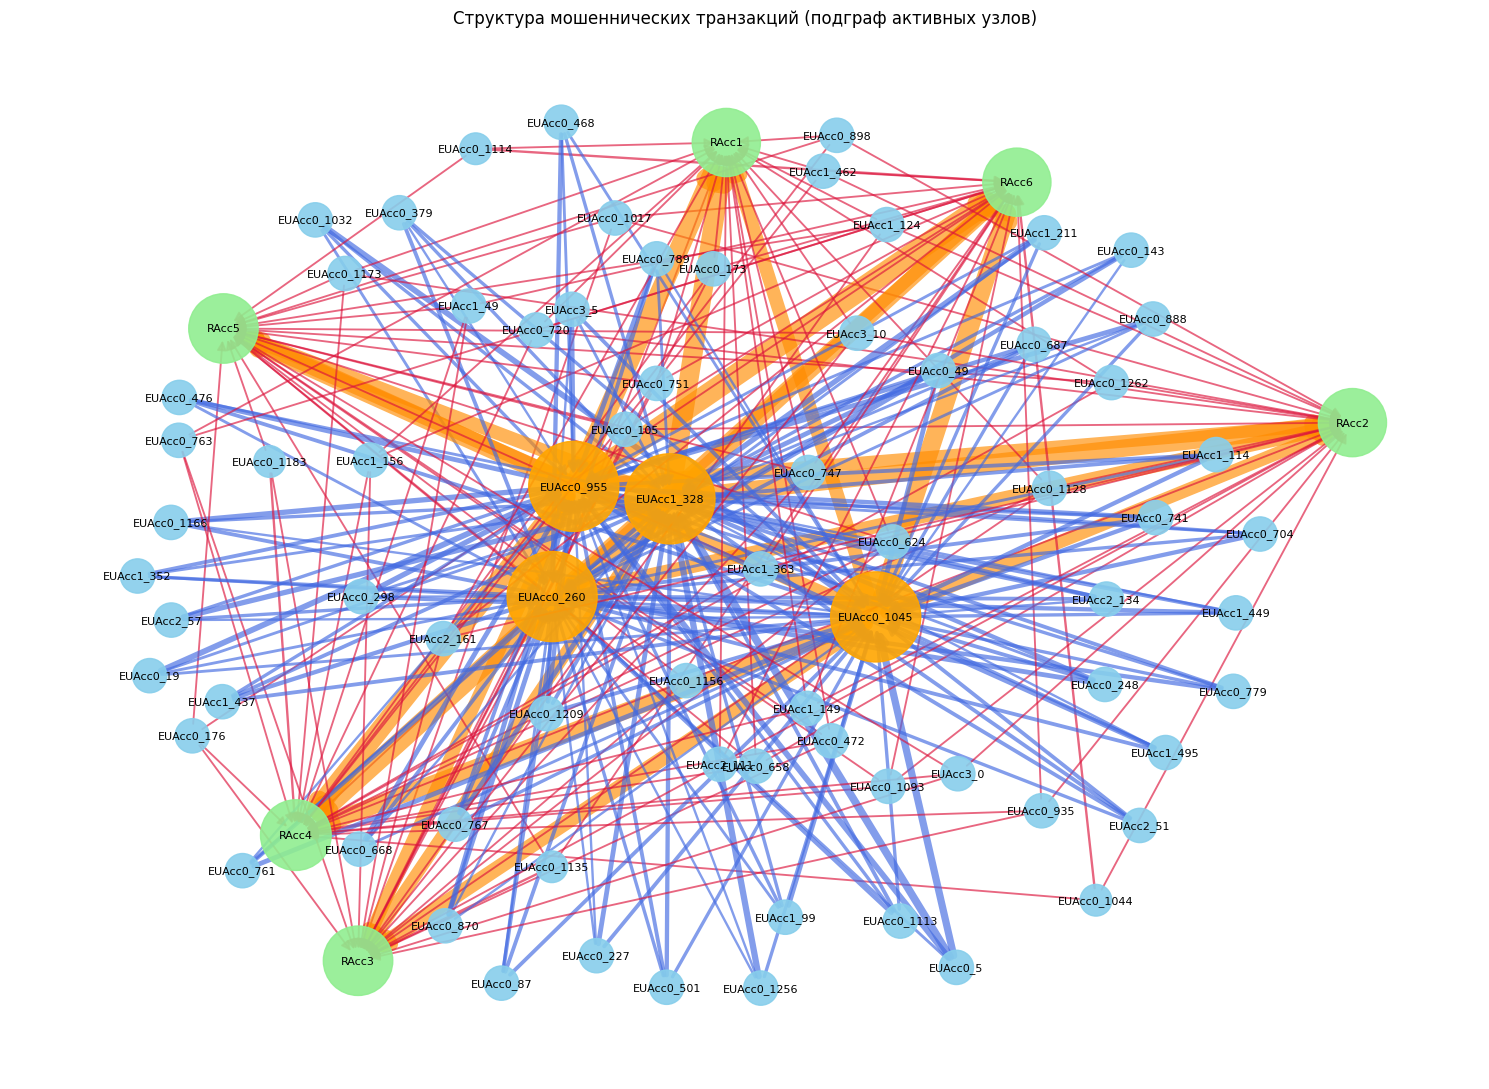

Pyvis-граф сохранён: fraud_graph_pyvis_alt.html


Основные наблюдения:

1. Какие мошеннические сценарии есть в данных:
   - F_bot: 721 транзакций, 39 уникальных отправителей, 4 уникальных получателей.
   - F-Mule-With: 717 транзакций, 4 уникальных отправителей, 6 уникальных получателей.
   - F_SevWith: 240 транзакций, 60 уникальных отправителей, 6 уникальных получателей.

2. Наиболее структурно важные узлы:
    account role_from_data  in_degree  out_degree   total_in  total_out structural_role
      RAcc4            RET         40           0 1569253.63       0.00            sink
 EUAcc0_955             EU         39           6 2057444.73 2018313.06             hub
 EUAcc1_328             EU         39           6 1939990.14 1920590.23             hub
 EUAcc0_260             EU         39           6 1873294.83  593377.53             hub
      RAcc6            RET         39           0 1845889.33       0.00            sink
      RAcc5            RET         39           0 1459387.01       0.00            sink
EUAcc0_1045            

In [48]:
df = load_transactions(DATA_PATH)
fraud_df = make_fraud_subset(df)
G = build_account_graph(fraud_df)

summary_df = fraud_summary(fraud_df)
node_df = classify_nodes(G)
by_day_df = time_summary(fraud_df)

print("Размер исходного набора:", df.shape)
print("Количество мошеннических транзакций:", fraud_df.shape[0])
print("Число узлов в графе:", G.number_of_nodes())
print("Число рёбер в графе:", G.number_of_edges())
print()

display(summary_df.head(10))
display(node_df.head(15))

plot_static_graph(G, max_nodes=80)
plot_timeline_plotly(by_day_df)
plot_network_plotly(G, max_nodes=70)
export_pyvis_graph(G, max_nodes=70, output_file="fraud_graph_pyvis_alt.html")

describe_patterns(summary_df, node_df)